In [1]:
import pandas as pd
import numpy as np
from glob import glob
import time

import arcgis
from arcgis.features import GeoAccessor, GeoSeriesAccessor
from arcgis.features.use_proximity import find_nearest

In [2]:
gis = GIS("https://geosaurus.maps.arcgis.com/", "rsingh_geosaurus", "P@ssw0rd@123")

In [8]:
root = r'c:/xc/github/zika' 

## Places with confirmed Zika infections

Uses CDC Epidemic Prediction Initiative's repository of publicly available Zika data - https://github.com/cdcepi/zika

In [3]:
location_files = glob(root +'/*/*Places.csv')

In [4]:
locations = pd.concat([pd.read_csv(x, encoding="ISO-8859-1")
                       for x in location_files], axis=0).reset_index(drop=True)

In [5]:
locations.head(1)

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province
0,Buenos Aires,BUENOS AIRES,NaN,Argentina,NaN,Argentina-Buenos_Aires,province,Buenos Aires


In [6]:
# clean up
locations.fillna('', inplace=True)
locations['country'] = locations.country.str.replace('_', ' ')

cols = locations.select_dtypes(include=[np.object]).columns
locations[cols] = locations[cols].apply(
    lambda x: x.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))

### Create address column

In [30]:
def get_address(location):
    addr_parts = location.split('-')
    addr = addr_parts[-1].replace('_', ' ')
    for part in addr_parts[-2::-1]:
        addr += ', ' + part.replace('_', ' ')
    return addr

In [8]:
locations['address'] = locations['location'].apply(get_address)

In [9]:
locations.head(1)

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address
0,Buenos Aires,BUENOS AIRES,,Argentina,,Argentina-Buenos_Aires,province,Buenos Aires,"Buenos Aires, Argentina"


### Create spatial dataframe

Create a spatially enabled dataframe, save it as a shapefile, and also import it into the GIS

In [10]:
spdf = pd.DataFrame.spatial.from_df(df=locations, sr=4326)

In [12]:
spdf.head()

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address,SHAPE
0,Buenos Aires,BUENOS AIRES,,Argentina,,Argentina-Buenos_Aires,province,Buenos Aires,"Buenos Aires, Argentina","{'x': -58.37343999999996, 'y': -34.60848999999..."
1,CABA,CABA,,Argentina,,Argentina-CABA,province,CABA,"CABA, Argentina","{'x': -58.37343999999996, 'y': -34.60848999999..."
2,Cordoba,CORDOBA,,Argentina,,Argentina-Cordoba,province,Cordoba,"Cordoba, Argentina","{'x': -64.18570999999997, 'y': -31.40717999999..."
3,Entre Rios,ENTRE RIOS,,Argentina,,Argentina-Entre_Rios,province,Entre Rios,"Entre Rios, Argentina","{'x': -59.200252396999986, 'y': -32.0606035709..."
4,Santa Fe,SANTA FE,,Argentina,,Argentina-Santa_Fe,province,Santa Fe,"Santa Fe, Argentina","{'x': -60.71202999999997, 'y': -31.63664999999..."


In [14]:
spdf.to_featureclass(out_location=root,
                         out_name="zika_locations.shp")

'c:/xc/github/zika\\zika_locations.shp'

In [15]:
zika_loc = gis.content.import_data(spdf, title='Locations with Zika')

In [16]:
zika_loc

<Item title:"Locations with Zika" type:Feature Layer Collection owner:rsingh_geosaurus>

In [69]:
zika_loc.itemid

'adb3f72bd0eb49c7b8f6a7b7d16cadae'

## Load Zika locations feature layer

In [9]:
zika_loc = gis.content.get('adb3f72bd0eb49c7b8f6a7b7d16cadae')

In [10]:
zikalyr = zika_loc.layers[0]

### Map locations of zika infections

In [5]:
m = gis.map('USA')
m

In [6]:
m.add_layer(zika_loc)

## Find airports nearest to Zika locations

### Load Airport locations

<Item title:"World Airport Locations" type:Feature Layer Collection owner:garycjohnsonDP>
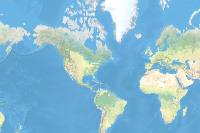

In [7]:
airports = gis.content.search('title: World Airport Locations owner:garycjohnsonDP', 'Feature Layer', outside_org=True)[0]
airports

In [8]:
airportlyr = airports.layers[0]

In [9]:
airportsdf = (pd
              .DataFrame
              .spatial
              .from_layer(airportlyr))

In [10]:
zikadf = zikalyr.query().sdf

In [11]:
zikadf.country.unique()

array(['Colombia', 'Dominican Republic', 'Ecuador', 'El Salvador',
       'France', 'Guatemala', 'Haiti', 'Mexico', 'Nicaragua', 'Panama',
       'United States', 'Argentina', 'Brazil'], dtype=object)

In [12]:
zikadf.columns

Index(['FID', 'address', 'alt_name1', 'alt_name2', 'city', 'country',
       'district_c', 'location', 'location_t', 'state_prov', 'SHAPE'],
      dtype='object')

### Find Nearest Airports from Zika locations using Spatial Analysis

In [13]:
def find_nearest_airports(location_filter, airport_filter):
    zikalyr.filter = location_filter
    airportlyr.filter = airport_filter
    
    nearest_airports = find_nearest(zikalyr, airportlyr, 'StraightLine', max_count=1,
                                    search_cutoff=100, search_cutoff_units='Miles')

    m.add_layer(nearest_airports['nearest_layer'])
    m.add_layer(nearest_airports['connecting_lines_layer'])
    
    nearestdf = nearest_airports['connecting_lines_layer'].query().sdf
    return nearestdf[['From_ID', 'From_Name', 'OID', 'To_Airport_Name', 'To_IATA', 'To_ICAO', 'To_ID', 'Total_Miles']]

In [14]:
location_airport_df = pd.DataFrame()

In [15]:
for country in zikadf.country.unique():
    print('Finding nearest airports for locations in: ' + country)
    try:
        location_filter = "Country = '{}'".format(country)
        airport_filter = "Country = '{}'".format(country.upper())

        if country == 'United States':
            airport_filter = "COUNTRY='USA' OR COUNTRY='PUERTO RICO'"

        df = find_nearest_airports(location_filter, airport_filter)

        location_airport_df = location_airport_df.append(df, ignore_index=True)
    except:
        print('Unable to find nearest airports for ' + country)

Finding nearest airports for locations in: Colombia


{"messageCode": "AO_100034", "message": "The number of features in adfc11 can not be greater than 1000.0.", "params": {"analysisLayer": "adfc11", "max": 1000.0}}
{"messageCode": "AO_100030", "message": "FindNearest failed."}
Failed to execute (FindNearest).
Failed.


Unable to find nearest airports for Colombia
Finding nearest airports for locations in: Dominican Republic
Finding nearest airports for locations in: Ecuador
Finding nearest airports for locations in: El Salvador
Finding nearest airports for locations in: France
Finding nearest airports for locations in: Guatemala
Finding nearest airports for locations in: Haiti
Finding nearest airports for locations in: Mexico
Finding nearest airports for locations in: Nicaragua
Finding nearest airports for locations in: Panama
Finding nearest airports for locations in: United States
Finding nearest airports for locations in: Argentina
Finding nearest airports for locations in: Brazil


In [16]:
airport_filter  = "Country = 'Colombia'"

location_filter = "Country = 'Colombia' AND FID < 1000"
df = find_nearest_airports(location_filter, airport_filter)
location_airport_df = location_airport_df.append(df, ignore_index=True)

location_filter = "Country = 'Colombia' AND FID >= 1000"
df = find_nearest_airports(location_filter, airport_filter)
location_airport_df = location_airport_df.append(df, ignore_index=True)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.


In [18]:
location_airport_df.head()

,From_ID,From_Name,OID,To_Airport_Name,To_IATA,To_ICAO,To_ID,Total_Miles
0,284,Dominican Republic,1,CONSTANZA,N/A,MDCZ,5772,15.041268
1,285,"Compostela, Azua, Dominican Republic",2,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,28.801449
2,286,"Barahona, Dominican Republic",3,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,3.187321
3,287,"Distrito Nacional, Dominican Republic",4,HERRERA INTERNATIONAL,HEX,MDHE,5038,1.970392
4,288,"Ensanche Ozama, Dominican Republic",5,HERRERA INTERNATIONAL,HEX,MDHE,5038,6.472363


In [21]:
loc_apt = root + '\\location_airport_df.pkl'
location_airport_df.to_pickle(loc_apt)

## Load nearest airports

In [35]:
loc_apt = root + '\\location_airport_df.pkl'
location_airport_df = pd.read_pickle(loc_apt)

In [36]:
location_airport_df.head()

,From_ID,From_Name,OID,To_Airport_Name,To_IATA,To_ICAO,To_ID,Total_Miles
0,284,Dominican Republic,1,CONSTANZA,N/A,MDCZ,5772,15.041268
1,285,"Compostela, Azua, Dominican Republic",2,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,28.801449
2,286,"Barahona, Dominican Republic",3,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,3.187321
3,287,"Distrito Nacional, Dominican Republic",4,HERRERA INTERNATIONAL,HEX,MDHE,5038,1.970392
4,288,"Ensanche Ozama, Dominican Republic",5,HERRERA INTERNATIONAL,HEX,MDHE,5038,6.472363


## Load infection data

In [13]:
data_file_locations = glob(root + '/*/*/data/*.csv')
data = pd.concat([pd.read_csv(x, encoding="ISO-8859-1")
                            for x in data_file_locations], axis=0).reset_index(drop=True)


In [14]:
data.drop(['Unnamed: 8', 'Unnamed: 9', 'time_period','time_period_type'], axis=1, inplace=True)

cols = data.select_dtypes(include=[np.object]).columns
data[cols] = data[cols].apply(
    lambda x: x.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))

In [15]:
# clean up - some columns are off 
data.dropna(subset=['unit'], inplace=True)

In [16]:
data['report_date'].fillna(data['ï»¿report_date'], inplace=True)
del data['ï»¿report_date']

data['report_date'] = data.report_date.str.replace('_','-')       
data['report_date'] = pd.to_datetime(data.report_date)

In [151]:
data.head()

,date,location,zika_cases,data_field
0,2017-01-12,Argentina-Buenos_Aires,0,cumulative_confirmed_imported_cases
1,2017-01-12,Argentina-CABA,1,cumulative_confirmed_imported_cases
2,2017-01-12,Argentina-Cordoba,2,cumulative_confirmed_imported_cases
3,2017-01-12,Argentina-Entre_Rios,0,cumulative_confirmed_imported_cases
4,2017-01-12,Argentina-Santa_Fe,2,cumulative_confirmed_imported_cases


In [18]:
# Drop municipalities
data = data.loc[data.unit!='municipalities']
data = (data[['report_date', 'location', 'value', 'data_field']]
             .rename(columns={'report_date':'date','value':'zika_cases'}))

In [19]:
data['zika_cases'] = data.zika_cases.fillna(0)
data['zika_cases'] = data.zika_cases.astype(int)

In [20]:
data.head()

,date,location,zika_cases,data_field
0,2017-01-12,Argentina-Buenos_Aires,0,cumulative_confirmed_imported_cases
1,2017-01-12,Argentina-CABA,1,cumulative_confirmed_imported_cases
2,2017-01-12,Argentina-Cordoba,2,cumulative_confirmed_imported_cases
3,2017-01-12,Argentina-Entre_Rios,0,cumulative_confirmed_imported_cases
4,2017-01-12,Argentina-Santa_Fe,2,cumulative_confirmed_imported_cases


In [21]:
data.query("zika_cases>0").shape, data.shape

((93268, 4), (230815, 4))

In [22]:
# Remove data that doesn't appear to be directly associated with Zika
excluded_fields = ['cumulative_cases_discarded',
'microcephaly_not',
'gbs_reported',
'zika_not',
'confirmed_acute_fever',
'confirmed_arthralgia',
'confirmed_arthritis', 
'confirmed_rash', 
'confirmed_conjunctivitis',
'confirmed_eyepain', 
'confirmed_headache', 
'confirmed_malaise',
'zika_reported_travel',
'yearly_reported_travel_cases']

mask = data.data_field.isin(excluded_fields)
print(mask.sum(), data.loc[mask, 'zika_cases'].sum(), data.zika_cases.sum())

6640 599059 17210158


In [23]:
data = data.loc[mask.pipe(np.invert)]

In [24]:
data.shape[0], data.zika_cases.sum()

(224175, 16611099)

In [25]:
data.dtypes

date          datetime64[ns]
location              object
zika_cases             int32
data_field            object
dtype: object

In [26]:
data_pkl = root + '\\infection_data_final.pkl'
data.to_pickle(data_pkl)

In [152]:
infection_data = pd.read_pickle(root + '\\infection_data_final.pkl')

In [153]:
infection_data.head()

,date,location,zika_cases,data_field
0,2017-01-12,Argentina-Buenos_Aires,0,cumulative_confirmed_imported_cases
1,2017-01-12,Argentina-CABA,1,cumulative_confirmed_imported_cases
2,2017-01-12,Argentina-Cordoba,2,cumulative_confirmed_imported_cases
3,2017-01-12,Argentina-Entre_Rios,0,cumulative_confirmed_imported_cases
4,2017-01-12,Argentina-Santa_Fe,2,cumulative_confirmed_imported_cases


In [154]:
infection_data['address'] = infection_data['location'].apply(get_address)

infection_data = infection_data[['date','address']]
infection_data.head(1)

In [37]:
location_airport_df.head()

,From_ID,From_Name,OID,To_Airport_Name,To_IATA,To_ICAO,To_ID,Total_Miles
0,284,Dominican Republic,1,CONSTANZA,N/A,MDCZ,5772,15.041268
1,285,"Compostela, Azua, Dominican Republic",2,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,28.801449
2,286,"Barahona, Dominican Republic",3,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,3.187321
3,287,"Distrito Nacional, Dominican Republic",4,HERRERA INTERNATIONAL,HEX,MDHE,5038,1.970392
4,288,"Ensanche Ozama, Dominican Republic",5,HERRERA INTERNATIONAL,HEX,MDHE,5038,6.472363


## Combine infection date with nearest airport

In [40]:
merge_all = pd.merge(infection_data, 
                     location_airport_df[['From_Name', 'To_Airport_Name', 'To_IATA', 'To_ICAO']], 
                     left_on='address', 
                     right_on='From_Name',
                     how='left').drop_duplicates()

In [41]:
merge_all.head()

,date,address,From_Name,To_Airport_Name,To_IATA,To_ICAO
0,2017-01-12,"Buenos Aires, Argentina","Buenos Aires, Argentina",AEROPARQUE JORGE NEWBERY,AEP,SABE
1,2017-01-12,"CABA, Argentina","CABA, Argentina",AEROPARQUE JORGE NEWBERY,AEP,SABE
2,2017-01-12,"Cordoba, Argentina","Cordoba, Argentina",AMBROSIO L V TARAVELLA,COR,SACO
3,2017-01-12,"Entre Rios, Argentina","Entre Rios, Argentina",GUALEGUAYCHU,GHU,SAAG
4,2017-01-12,"Santa Fe, Argentina","Santa Fe, Argentina",SAUCE VIEJO,SFN,SAAV


In [42]:
merge_all.shape

(67794, 6)

In [43]:
merge_all.rename(columns={'To_IATA':'IATA','To_ICAO':'ICAO'}, inplace=True)

## Scrape weather data

In [85]:
from datetime import timedelta

weather_scrape = (merge_all[['date','IATA','ICAO']]
                  .drop_duplicates()
                  .set_index(['IATA','ICAO']))

weather_scrape['date1'] = weather_scrape.date - timedelta(days=7)
weather_scrape['date2'] = weather_scrape.date - timedelta(days=14)
weather_scrape.head()

,,date,date1,date2
IATA,ICAO,,,
AEP,SABE,2017-01-12,2017-01-05,2016-12-29
COR,SACO,2017-01-12,2017-01-05,2016-12-29
GHU,SAAG,2017-01-12,2017-01-05,2016-12-29
SFN,SAAV,2017-01-12,2017-01-05,2016-12-29
N/A,SAMQ,2017-01-12,2017-01-05,2016-12-29


In [86]:
weather_scrape = (weather_scrape
                  .stack()
                  .reset_index(level=-1, drop=True)
                  .reset_index()
                  .rename(columns={0:'date'})
                  .dropna(subset=['IATA','ICAO'], how='all')
                 )

weather_scrape.head()

,IATA,ICAO,date
0,AEP,SABE,2017-01-12
1,AEP,SABE,2017-01-05
2,AEP,SABE,2016-12-29
3,COR,SACO,2017-01-12
4,COR,SACO,2017-01-05


In [105]:
len(weather_scrape)

37479

In [102]:
def scrape_weekly_weather(date, df_row):
    # Scrape the weekly data table
    url_fmt = 'https://www.wunderground.com/history/airport/{}/{}/{}/{}/WeeklyHistory.html'
    try:
        url = url_fmt.format(df_row.ICAO, date.year, 
                             date.month, date.day)
        print(url)
    
    except:
        url = url_fmt.format(df_row.IATA, date.year, 
                             date.month, date.day)
        print("EEE"+url)
    
    try:
        table = pd.read_html(url)[0].dropna(subset=['Max','Avg','Min','Sum'], how='all')
        table.columns = ['Measurement','Max','Avg','Min','Sum']
        table.set_index('Measurement', inplace=True)
        table = table.stack()
        time.sleep(1.0)
    except:
        print('ERRRORRR')
        table = pd.Series({'NULL':np.NaN}, index=pd.Index([0]))
    
    return table

In [109]:
for index, row in weather_scrape[:5].iterrows():
    date = row['date']
    scrape_weekly_weather(date, row)

2017-01-12 00:00:00
IATA                    AEP
ICAO                   SABE
date    2017-01-12 00:00:00
Name: 0, dtype: object
2017-01-05 00:00:00
IATA                    AEP
ICAO                   SABE
date    2017-01-05 00:00:00
Name: 1, dtype: object
2016-12-29 00:00:00
IATA                    AEP
ICAO                   SABE
date    2016-12-29 00:00:00
Name: 2, dtype: object
2017-01-12 00:00:00
IATA                    COR
ICAO                   SACO
date    2017-01-12 00:00:00
Name: 3, dtype: object
2017-01-05 00:00:00
IATA                    COR
ICAO                   SACO
date    2017-01-05 00:00:00
Name: 4, dtype: object


In [103]:
date = weather_scrape['date'].iloc[0]
df_row = weather_scrape.iloc[0]

In [104]:
scrape_weekly_weather(date, df_row)

https://www.wunderground.com/history/airport/SABE/2017/1/12/WeeklyHistory.html


Measurement                       
Max Temperature                Max       87 °F
                               Avg       84 °F
                               Min       79 °F
Mean Temperature               Max       80 °F
                               Avg       76 °F
                               Min       72 °F
Min Temperature                Max       71 °F
                               Avg       69 °F
                               Min       64 °F
Heating Degree Days (base 65)  Max           0
                               Avg           0
                               Min           0
                               Sum           0
Cooling Degree Days (base 65)  Max          14
                               Avg          11
                               Min           6
                               Sum          79
Growing Degree Days (base 50)  Max          30
                               Avg          26
                               Min          22
                         

In [76]:
weather_scrape.iloc[0]

IATA                    AEP
ICAO                   SABE
date    2017-01-12 00:00:00
Name: 0, dtype: object

In [78]:
url_fmt = 'https://www.wunderground.com/history/airport/{}/{}/{}/{}/WeeklyHistory.html'

In [79]:
url = url_fmt.format(df_row.ICAO, date.year, 
                             date.month, date.day)

In [80]:
table = pd.read_html(url)

In [81]:
url

'https://www.wunderground.com/history/airport/SABE/2017/1/12/WeeklyHistory.html'

In [82]:
table

[                                        Max       Avg       Min      Sum
 0                     Temperature       NaN       NaN       NaN      NaN
 1                 Max Temperature     87 °F     84 °F     79 °F      NaN
 2                Mean Temperature     80 °F     76 °F     72 °F      NaN
 3                 Min Temperature     71 °F     69 °F     64 °F      NaN
 4                     Degree Days       NaN       NaN       NaN      NaN
 5   Heating Degree Days (base 65)         0         0         0        0
 6   Cooling Degree Days (base 65)        14        11         6       79
 7   Growing Degree Days (base 50)        30        26        22      185
 8                       Dew Point       NaN       NaN       NaN      NaN
 9                       Dew Point     75 °F     64 °F     48 °F      NaN
 10                  Precipitation       NaN       NaN       NaN      NaN
 11                  Precipitation   0.91 in   0.14 in   0.00 in  0.95 in
 12                      Snowdepth    

In [83]:
weather_scrape.shape

(37479, 3)

In [88]:
for num,(row,dat) in enumerate(airport_list.iterrows()):
     print(num)

NameError: name 'airport_list' is not defined

In [87]:
for ndate, date in enumerate(weather_scrape):
    
    print(ndate)
    print(date)
    df_list = list()
    
    for num,(row,dat) in enumerate(airport_list.iterrows()):
        
        try:
            df = scrape_weekly_weather(date, dat)
        except:
            df = pd.Series({'NULL':np.NaN}, index=pd.Index([row]))

        df_list.append((date, dat.name, df))
        
    with open(root + '/04_scrape_weekly_weather_data/df_list{}.pkl'.format(ndate),'w') as fh:
        dill.dump(df_list, fh)

0
IATA
1
ICAO
2
date


## Mosquito sightings

<Item title:"Aedes Worldwide Points" type:Feature Layer Collection owner:dattaway_wdcintel>
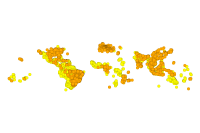

<Item title:"2016 CDC estimated Aedes albopictus Habitat USA" type:Feature Layer Collection owner:dattaway_wdcintel>
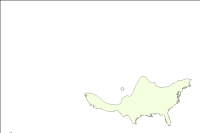

<Item title:"SemZika" type:Feature Layer Collection owner:AdmProjEstr>
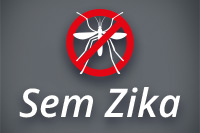

In [111]:
aedesitems = gis.content.search('Aedes aegypti', 'feature layer', outside_org=True, max_items=3)
for item in aedesitems:
    display(item)

In [117]:
aedessightings = aedesitems[0]

In [118]:
aedessightings.layers

[<FeatureLayer url:"https://services5.arcgis.com/cMBqYE4wmbXNMvex/arcgis/rest/services/Aedes_Worldwide_Points/FeatureServer/0">]

In [119]:
aedes = aedessightings.layers[0]

In [121]:
aedesdf = aedes.query().sdf

In [122]:
aedesdf.columns

Index(['COUNTRY', 'COUNTRY_ID', 'GAUL_AD0', 'LOCATION_T', 'OBJECTID',
       'OCCURRENCE', 'POLYGON_AD', 'SOURCE_TYP', 'STATUS', 'VECTOR', 'X', 'Y',
       'YEAR', 'SHAPE'],
      dtype='object')

In [125]:
aedesdf.head()

,COUNTRY,COUNTRY_ID,GAUL_AD0,LOCATION_T,OBJECTID,OCCURRENCE,POLYGON_AD,SOURCE_TYP,STATUS,VECTOR,X,Y,YEAR,SHAPE
0,Kenya,KEN,133,point,1,1,-999,published,NA,Aedes aegypti,40.07,-3.22,1958,"{'y': -3.220000000299706, 'x': 40.06999999970026}"
1,Congo,COG,59,point,2,2,-999,published,NA,Aedes aegypti,15.30,-4.27,1960,"{'y': -4.269999999999925, 'x': 15.300000000099..."
2,Congo,COG,59,point,3,3,-999,published,NA,Aedes aegypti,15.30,-4.27,1960,"{'y': -4.269999999999925, 'x': 15.300000000099..."
3,Kenya,KEN,133,point,4,4,-999,published,NA,Aedes aegypti,40.07,-3.22,1960,"{'y': -3.220000000299706, 'x': 40.06999999970026}"
4,Kenya,KEN,133,point,5,5,-999,published,NA,Aedes aegypti,40.14,-3.04,1960,"{'y': -3.040000000299699, 'x': 40.140000000099..."


In [135]:
len(aedesdf)

41366

In [136]:
aedesdf = aedesdf.loc[aedesdf.YEAR >= 2006]

In [138]:
len(aedesdf)

23947

In [139]:
aedesdf.COUNTRY.unique()

array(['Indonesia', 'Argentina', 'Paraguay', 'Brazil', 'Bolivia',
       'Australia', 'Mayotte', 'Peru', 'Gabon', 'Colombia',
       'French Guiana', 'Cameroon', 'Philippines', 'Nigeria', 'Venezuela',
       'India', 'Sri Lanka', 'Costa Rica', 'Viet Nam',
       'Trinidad and Tobago', 'Senegal', 'Thailand', 'Mexico',
       'Guadeloupe', 'Myanmar', 'Puerto Rico', 'Cuba', 'Saudi Arabia',
       'Bangladesh', 'United States of America', 'Uruguay', 'Madagascar',
       'R?union', 'Comoros', 'Glorioso Island', 'Kenya', 'Malaysia',
       'Maldives', 'Nicaragua', 'El Salvador', 'Cayman Islands', 'Taiwan',
       'China', 'Japan', 'New Caledonia', 'Uganda', 'Singapore',
       "C?te d'Ivoire", 'Martinique', 'Yemen', 'Sudan', 'French Polynesia',
       'Antigua and Barbuda', 'Pakistan', 'Central African Republic',
       'Saint Kitts and Nevis', 'Tonga', 'Congo',
       "Lao People's Democratic Republic", 'Zambia', 'Georgia',
       'Montenegro', 'Turkey', 'Hong Kong', 'Korea, Republic of',
 

## Population Density

<Item title:"World Population Estimated Density 2015" type:Imagery Layer owner:esri>
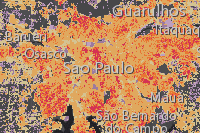

In [141]:
gis.content.search('title:"World Population Estimated Density 2015" owner:esri', 'Imagery layer', outside_org=True)[0]

<Item title:"World Population Estimated Density 2015" type:Imagery Layer owner:esri>
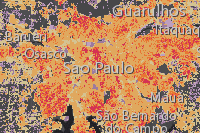

In [135]:
popdensity = gis.content.get('625e9da1afed40b78aaf412f519b22d3')
popdensity

In [144]:
pop_density = popdensity.layers[0]

In [152]:
pop_density.get_samples(zikadf['SHAPE'].iloc[0])

[{'location': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
   'x': -8193570.932297183,
   'y': 708247.432304714},
  'locationId': 0,
  'rasterId': 1,
  'resolution': 0.002069203345212093,
  'value': '5520'}]

## GDP per capita

<Item title:"Gross Domestic Product Per Capita, 1960-2016, From World Bank" type:Feature Layer Collection owner:dianaclavery_uo>
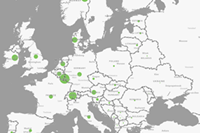

In [146]:
gdp_pc =  gis.content.search('Gross Domestic Product Per Capita, 1960-2016, From World Bank', outside_org=True)[0]
gdp_pc

In [148]:
gdp_lyr = gdp_pc.layers[0]

In [149]:
gdp_df = gdp_lyr.query().sdf

In [150]:
gdp_df.head()

,Country_Code,Country_Name,FID,GDP_PerCapita_1960,GDP_PerCapita_1961,GDP_PerCapita_1962,GDP_PerCapita_1963,GDP_PerCapita_1964,GDP_PerCapita_1965,GDP_PerCapita_1966,...,GDP_PerCapita_2008,GDP_PerCapita_2009,GDP_PerCapita_2010,GDP_PerCapita_2011,GDP_PerCapita_2012,GDP_PerCapita_2013,GDP_PerCapita_2014,GDP_PerCapita_2015,GDP_PerCapita_2016,SHAPE
0,LBN,Lebanon,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7012.775759,8400.268878,8763.826274,8734.900653,8787.946608,8406.285153,8161.461400,8046.632851,7914.004677,"{'y': 4018258.9021999985, 'x': 3995638.099300001}"
1,LBR,Liberia,2,NaN,NaN,163.917196,167.291564,178.813389,182.973602,190.565039,...,232.061732,303.066749,327.420510,379.689580,415.036196,454.122224,458.465173,452.038072,455.370741,"{'y': 719234.3707999997, 'x': -1036427.4921000..."
2,ABW,Aruba,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27546.899390,24631.434860,24271.940420,25324.720360,NaN,NaN,NaN,NaN,NaN,"{'y': 1403707.1539000012, 'x': -7789073.475500..."
3,AFG,Afghanistan,4,NaN,NaN,58.492874,78.782758,82.208444,101.290471,137.899362,...,373.361116,445.893298,553.300289,603.537023,669.009051,631.744971,612.069651,584.025902,561.778746,"{'y': 4006150.334299997, 'x': 7349837.296999998}"
4,LBY,Libya,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14396.048650,10296.973530,12120.562170,5602.549434,NaN,NaN,NaN,NaN,NaN,"{'y': 3128698.683699999, 'x': 2007181.568}"


## Class Balancing

In [156]:
infection_data.head()

,date,location,zika_cases,data_field,address
0,2017-01-12,Argentina-Buenos_Aires,0,cumulative_confirmed_imported_cases,"Buenos Aires, Argentina"
1,2017-01-12,Argentina-CABA,1,cumulative_confirmed_imported_cases,"CABA, Argentina"
2,2017-01-12,Argentina-Cordoba,2,cumulative_confirmed_imported_cases,"Cordoba, Argentina"
3,2017-01-12,Argentina-Entre_Rios,0,cumulative_confirmed_imported_cases,"Entre Rios, Argentina"
4,2017-01-12,Argentina-Santa_Fe,2,cumulative_confirmed_imported_cases,"Santa Fe, Argentina"


In [157]:
infection_data.dtypes

date          datetime64[ns]
location              object
zika_cases             int32
data_field            object
address               object
dtype: object

In [159]:
infection_sum = (infection_data[['date','location','zika_cases']]
                 .groupby(['date','location'], as_index=False)
                 .sum())

In [161]:
infection_sum.head()

,date,location,zika_cases
0,2015-11-28,El_Salvador,854
1,2015-11-28,El_Salvador-Ahuachapan,4
2,2015-11-28,El_Salvador-Cabanas,3
3,2015-11-28,El_Salvador-Chalatenango,8
4,2015-11-28,El_Salvador-Cuscatlan,4


In [162]:
def feasibility(df):
    cases_first_date = df.loc[df.date==df.date.min(), 'zika_cases'].values[0]
    date_first_date  = df.date.min()
    
    cases_max   = df.zika_cases.max()
    date_max    = df.loc[df.zika_cases==df.zika_cases.max(), 'date'].values[0]
    
    cases_last  = df.loc[df.date==df.date.max(), 'zika_cases'].values[0]
    date_last   = df.date.max()
    
    cases_total = df.zika_cases.sum()
    
    df2 = df.loc[df.zika_cases>0]
    
    if df2.shape[0]>=1:
        cases_first_nonzero = df2.loc[df2.date==df2.date.min(),'zika_cases'].values[0]
        date_first_nonzero  = df2.date.min()
    else:
        cases_first_nonzero = np.NaN
        date_first_nonzero = np.NaN
        
    #print(type(date_first_date), type(date_max), type(date_last), type(date_first_nonzero))
        
    return pd.Series({'cases_first_date' : cases_first_date,
                      'date_first_date'  : date_first_date,
                      'cases_first_nonzero' : cases_first_nonzero,
                      'date_first_nonzero'  : date_first_nonzero,
                      'cases_max'  : cases_max,
                      'date_max'   : date_max,
                      'cases_last' : cases_last,
                      'date_last'  : date_last,
                      'cases_total': cases_total})

In [163]:
framework_key = (infection_sum
                   .groupby('location')
                   .apply(feasibility))

In [164]:

framework_key.head(1)

,cases_first_date,cases_first_nonzero,cases_last,cases_max,cases_total,date_first_date,date_first_nonzero,date_last,date_max
location,,,,,,,,,
Argentina-Buenos_Aires,130,130.0,5,181,793,2016-03-28 00:00:00,2016-03-28 00:00:00,2017-06-19 00:00:00,2016-04-16T00:00:00.000000000


In [165]:
# Total size
print(framework_key.shape[0])

# Completely zero entries
print(framework_key.query('cases_max==0').shape[0])

# No zeros at all
print(framework_key.query('cases_first_date>0').shape[0])

# Number of entries that start at zero and have cases
print( ((framework_key.cases_max>0) & (framework_key.cases_first_date==0)).sum())

1765
307
865
593


In [166]:
framework_key['date_max'] = pd.to_datetime(framework_key.date_max)
framework_key['date_last'] = pd.to_datetime(framework_key.date_last)
framework_key['date_first_date'] = pd.to_datetime(framework_key.date_first_date)
framework_key['date_first_nonzero'] = pd.to_datetime(framework_key.date_first_nonzero)

In [167]:
framework_key.dtypes


cases_first_date                int64
cases_first_nonzero           float64
cases_last                      int64
cases_max                       int64
cases_total                     int64
date_first_date        datetime64[ns]
date_first_nonzero     datetime64[ns]
date_last              datetime64[ns]
date_max               datetime64[ns]
dtype: object

In [168]:
mask = framework_key.cases_max > 0

framework_a_first = pd.concat([(framework_key
                                .loc[mask, ['date_first_nonzero']]
                                .assign(zika_bool=1)
                                .rename(columns={'date_first_nonzero':'date'})),
                               
                                # zero case data are taken from first date
                               (framework_key
                                .loc[mask.pipe(np.invert), ['date_first_date']]
                                .assign(zika_bool=0)
                                .rename(columns={'date_first_date':'date'}))]).sort_index().reset_index()


framework_a_max  = pd.concat([(framework_key
                                .loc[mask, ['date_max']]
                                .assign(zika_bool=1)
                                .rename(columns={'date_max':'date'})),
                              
                                # zero case data are taken from first date
                               (framework_key
                                .loc[mask.pipe(np.invert), ['date_first_date']]
                                .assign(zika_bool=0)
                                .rename(columns={'date_first_date':'date'}))]).sort_index().reset_index()

In [169]:
framework_key.head()


,cases_first_date,cases_first_nonzero,cases_last,cases_max,cases_total,date_first_date,date_first_nonzero,date_last,date_max
location,,,,,,,,,
Argentina-Buenos_Aires,130,130.0,5,181,793,2016-03-28,2016-03-28,2017-06-19,2016-04-16
Argentina-CABA,77,77.0,3,95,647,2016-03-28,2016-03-28,2017-06-19,2016-04-16
Argentina-Catamarca,14,14.0,0,15,59,2016-03-28,2016-03-28,2017-06-19,2016-04-02
Argentina-Chaco,48,48.0,50,57,460,2016-03-28,2016-03-28,2017-06-19,2016-04-16
Argentina-Chubut,6,6.0,0,6,47,2016-03-28,2016-03-28,2017-06-19,2016-03-28


In [170]:
mask = framework_key.cases_max > 0

fwf = pd.concat([(framework_key
                                .loc[mask, ['date_first_nonzero','cases_first_date','cases_total']]
                                .assign(zika_bool=1)
                                .rename(columns={'date_first_nonzero':'date'})),
                               
                                # zero case data are taken from first date
                               (framework_key
                                .loc[mask.pipe(np.invert), ['date_first_date']]
                                .assign(zika_bool=0)
                                .rename(columns={'date_first_date':'date'}))]).sort_index().reset_index()

fwf['cases_first_date'] = fwf.cases_first_date.fillna(0).astype(np.int)
fwf['cases_total'] = fwf.cases_total.fillna(0).astype(np.int)

fwf.to_pickle(root+'/10_class_balancing_fwf.pkl')

In [171]:
framework_a_first.head(1).T

,0
location,Argentina-Buenos_Aires
date,2016-03-28 00:00:00
zika_bool,1


In [173]:
fwf.head(1).T

,0
location,Argentina-Buenos_Aires
cases_first_date,130
cases_total,793
date,2016-03-28 00:00:00
zika_bool,1


In [174]:
framework_a_first.zika_bool.value_counts()

1    1458
0     307
Name: zika_bool, dtype: int64

In [175]:
framework_a_max.zika_bool.value_counts()

1    1458
0     307
Name: zika_bool, dtype: int64